# Análise Exploratória de Dados (AED)

## 1. Apresentação da análise

### 1.1. Problema analítico
A *Online Shop* trata toda a base de clientes de forma uniforme nas campanhas de marketing, sem inteligência sobre o comportamento de recompra. Isso gera dois custos: clientes fiéis recebem promoções desnecessárias (corroendo margem e elevando o *opt-out*) e orçamento é desperdiçado com clientes já inativos. O objetivo desta AED é **diagnosticar padrões de engajamento, inatividade e geração de receita** que apoiem decisões de marketing mais segmentadas.

### 1.2. Perguntas investigáveis
- **Q1.** Como o tempo de inatividade desde a última compra distribui os clientes e quem compõe o maior risco?
- **Q2.** Qual é o volume de recompra necessário para que um cliente faça parte dos mais fiéis à loja?
- **Q3.** Qual é a relação entre o comportamento de compra dos clientes e o retorno financeiro que eles geram?

### 1.3. Dataset utilizado
*Online Shop 2024 Dataset* (Kaggle), já processado pelo pipeline do projeto até a **camada gold** (arquitetura *medallion*: bronze → silver → gold). A camada gold consolida o histórico transacional em um perfil **RFM** (Recência, Frequência, Valor) por cliente.

### 1.4. Unidade de análise
O **cliente** (`customer_id`). Cada linha representa um cliente único; pedidos, itens e pagamentos já foram agregados a esse nível.

### 1.5. Versão dos dados
Camada **gold** do pipeline (dados de 2024). Esta AED não altera os dados; consome a versão consolidada.

### 1.6. Escopo da análise exploratória
Análise **exploratória e descritiva**: descrição das variáveis, distribuições, dispersão, outliers, relações iniciais e padrões. Não inclui modelagem preditiva nem inferência causal; conclusões definitivas ficam para etapas posteriores do pipeline.

## 2. Visão geral do dataset

### 2.1. Importação dos pacotes

- `pandas`: manipulação e análise de dados tabulares;
- `numpy`: operações numéricas auxiliares;
- `pathlib`: path do dataset;
- `seaborn`: carregamento do dataset e visualização estatística;
- `matplotlib.pyplot`: configuração e exibição de gráficos.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Configurações visuais
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 2)

# Caminho dataset
PATH_GOLD   = Path('../datasets/dataset_gold/')

print(f'Gold:   {PATH_GOLD.resolve()}')

Gold:   C:\Users\milena\Downloads\icd\datasets\dataset_gold


### 2.2. Carregamento do dataset

Cada linha representa um cliente.

In [2]:
df = pd.read_parquet(PATH_GOLD / "dataset_gold.parquet")

df.head()

,customer_id,primeira_compra,ultima_compra,recencia_dias,score_recencia,frequencia,score_frequencia,is_recomprador,score_frequencia_monetario,valor_monetario,score_monetario,ticket_medio,score_rfm,segmento_cliente
0,1,2024-03-01,2024-05-02,187,2,2,1,True,1,1096.70,1,548.35,4,Em Risco
1,2,2024-05-22,2024-05-22,167,2,1,1,False,3,4378.05,3,4378.05,6,Em Risco
2,3,2024-07-10,2024-07-10,118,3,1,1,False,3,3177.20,3,3177.20,7,Leal
3,4,2024-06-02,2024-06-02,156,3,1,1,False,1,670.56,1,670.56,5,Em Risco
4,5,2023-12-06,2023-12-06,335,1,1,1,False,4,6153.80,4,6153.80,6,Em Risco


### 2.3. Dimensão do dataset

In [3]:
linhas, colunas = df.shape

print(f"Número de linhas: {linhas}")
print(f"Número de colunas: {colunas}")

Número de linhas: 10000
Número de colunas: 14


A base reúne **10.000 clientes** descritos por **14 atributos**. A granularidade (um cliente por linha) é coerente com a unidade de análise definida e com as perguntas Q1–Q3, todas formuladas no nível do cliente.

### 2.4. Estrutura das variáveis


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 10000 non-null  int64         
 1   primeira_compra             10000 non-null  datetime64[us]
 2   ultima_compra               10000 non-null  datetime64[us]
 3   recencia_dias               10000 non-null  int64         
 4   score_recencia              10000 non-null  int64         
 5   frequencia                  10000 non-null  int64         
 6   score_frequencia            10000 non-null  int64         
 7   is_recomprador              10000 non-null  bool          
 8   score_frequencia_monetario  10000 non-null  int64         
 9   valor_monetario             10000 non-null  float64       
 10  score_monetario             10000 non-null  int64         
 11  ticket_medio                10000 non-null  float64    

Há três blocos de variáveis: identificador (`customer_id`), datas (`primeira_compra`, `ultima_compra`) e as métricas RFM derivadas (recência, frequência, valor e seus *scores*). Os tipos estão coerentes datas como `datetime`, métricas como numéricas, `is_recomprador` como booleano e `segmento_cliente` como texto.

### 2.5. Valores ausentes

In [5]:
missing = df.isnull().sum()

missing

customer_id                   0
primeira_compra               0
ultima_compra                 0
recencia_dias                 0
score_recencia                0
frequencia                    0
score_frequencia              0
is_recomprador                0
score_frequencia_monetario    0
valor_monetario               0
score_monetario               0
ticket_medio                  0
score_rfm                     0
segmento_cliente              0
dtype: int64

Não foram identificados valores ausentes.

### 2.5. Valores duplicados

In [6]:
df.duplicated().sum()

np.int64(0)

Não foram identificados registros duplicados.

### 2.6. Identificação de variáveis numéricas e categóricas

In [7]:
# Papéis analíticos explícitos (usados no restante do notebook)
metricas_numericas = ["recencia_dias", "frequencia", "valor_monetario", "ticket_medio"]
scores_ordinais    = ["score_recencia", "score_frequencia", "score_monetario",
                      "score_frequencia_monetario", "score_rfm"]
categoricas_aed    = scores_ordinais + ["is_recomprador", "segmento_cliente"]

print("Métricas numéricas:", metricas_numericas)
print("Scores ordinais   :", scores_ordinais)
print("Categóricas (AED) :", categoricas_aed)

Métricas numéricas: ['recencia_dias', 'frequencia', 'valor_monetario', 'ticket_medio']
Scores ordinais   : ['score_recencia', 'score_frequencia', 'score_monetario', 'score_frequencia_monetario', 'score_rfm']
Categóricas (AED) : ['score_recencia', 'score_frequencia', 'score_monetario', 'score_frequencia_monetario', 'score_rfm', 'is_recomprador', 'segmento_cliente']


### 2.8. Variáveis selecionadas para a AED e justificativa

Organizamos as variáveis por papel analítico:

| Papel | Variáveis | Uso na AED |
|---|---|---|
| **Métricas numéricas (RFM)** | `recencia_dias`, `frequencia`, `valor_monetario`, `ticket_medio` | Estatística descritiva, distribuições, dispersão, outliers, correlação |
| **Scores ordinais (1–4)** | `score_recencia`, `score_frequencia`, `score_monetario`, `score_frequencia_monetario`, `score_rfm` | Tratados como **categóricos ordinais**: frequências e contraste entre grupos |
| **Indicador / segmento** | `is_recomprador`, `segmento_cliente` | Comparações entre grupos e proporções condicionais |
| **Excluídas da análise direta** | `customer_id`, `primeira_compra`, `ultima_compra` | `customer_id` é apenas identificador; as datas brutas servem para derivar recência e tendência temporal, não para estatística descritiva |

**Decisão sobre os `score_*`:** por serem notas de 1 a 4 (escala ordinal), são analisados como categóricos ordinais (frequências, *countplots*), e não com média/desvio como se fossem contínuos. *(Pendência confirmada com o grupo; ajuste aqui se a convenção do projeto for outra.)*

## 3. Descrição estatística

### 3.1. Resumo estatístico geral das variáveis numéricas

- `count`: quantidade de valores não ausentes;
- `mean`: média;
- `std`: desvio-padrão;
- `min`: menor valor;
- `25%`: primeiro quartil;
- `50%`: mediana;
- `75%`: terceiro quartil;
- `max`: maior valor.

In [8]:
df[metricas_numericas].describe()

,recencia_dias,frequencia,valor_monetario,ticket_medio
count,10000.00,10000.0,10000.00,10000.00
mean,168.74,1.2,3402.31,2831.02
std,104.62,0.4,2738.80,2153.52
min,1.00,1.0,24.58,24.58
25%,77.00,1.0,1140.45,1033.22
50%,162.00,1.0,2720.95,2334.92
75%,257.00,1.0,5049.95,4147.64
max,366.00,2.0,19651.70,10082.72


### 3.2. Média e mediana das variáveis numéricas

In [9]:
media_mediana = pd.DataFrame({
    "media": df[metricas_numericas].mean(),
    "mediana": df[metricas_numericas].median()
})
media_mediana["dif_media_mediana"] = media_mediana["media"] - media_mediana["mediana"]
media_mediana

,media,mediana,dif_media_mediana
recencia_dias,168.74,162.00,6.74
frequencia,1.20,1.00,0.20
valor_monetario,3402.31,2720.95,681.36
ticket_medio,2831.02,2334.92,496.10


### 3.3. Mínimo, máximo e amplitude inicial das variáveis numéricas


In [11]:
limites = pd.DataFrame({
    "minimo": df[metricas_numericas].min(),
    "maximo": df[metricas_numericas].max()
})
limites["amplitude"] = limites["maximo"] - limites["minimo"]
limites

,minimo,maximo,amplitude
recencia_dias,1.00,366.00,365.00
frequencia,1.00,2.00,1.00
valor_monetario,24.58,19651.70,19627.12
ticket_medio,24.58,10082.72,10058.14


### 3.5. Quartis das variáveis numéricas

In [12]:
quartis = df[metricas_numericas].quantile([0.25, 0.50, 0.75])
quartis.index = ["Q1_25%", "Q2_50%_mediana", "Q3_75%"]
quartis

,recencia_dias,frequencia,valor_monetario,ticket_medio
Q1_25%,77.0,1.0,1140.45,1033.22
Q2_50%_mediana,162.0,1.0,2720.95,2334.92
Q3_75%,257.0,1.0,5049.95,4147.64


### 3.6. Frequências absolutas das variáveis categóricas

In [13]:
for coluna in categoricas_aed:
    print(f"\nFrequência absoluta — {coluna}")
    display(df[coluna].value_counts(dropna=False).to_frame(name="frequencia"))


Frequência absoluta — score_recencia


,frequencia
score_recencia,
4,2517
2,2505
1,2492
3,2486



Frequência absoluta — score_frequencia


,frequencia
score_frequencia,
1,10000



Frequência absoluta — score_monetario


...

,frequencia
score_rfm,
6,2303
7,1882
5,1766
4,1331
8,1284
9,718
3,716



Frequência absoluta — is_recomprador


,frequencia
is_recomprador,
False,8000
True,2000



Frequência absoluta — segmento_cliente


,frequencia
segmento_cliente,
Em Risco,5400
Leal,3884
Inativo,716


### 3.7. Frequências relativas das variáveis categóricas


In [14]:
for coluna in categoricas_aed:
    print(f"\nProporção — {coluna}")
    prop = df[coluna].value_counts(normalize=True, dropna=False).to_frame(name="proporcao")
    prop["percentual"] = prop["proporcao"] * 100
    display(prop)


Proporção — score_recencia


,proporcao,percentual
score_recencia,,
4,0.25,25.17
2,0.25,25.05
1,0.25,24.92
3,0.25,24.86



Proporção — score_frequencia


,proporcao,percentual
score_frequencia,,
1,1.0,100.0



Proporção — score_monetario


...

,proporcao,percentual
score_rfm,,
6,0.23,23.03
7,0.19,18.82
5,0.18,17.66
4,0.13,13.31
8,0.13,12.84
9,0.07,7.18
3,0.07,7.16



Proporção — is_recomprador


,proporcao,percentual
is_recomprador,,
False,0.8,80.0
True,0.2,20.0



Proporção — segmento_cliente


,proporcao,percentual
segmento_cliente,,
Em Risco,0.54,54.00
Leal,0.39,38.84
Inativo,0.07,7.16


As proporções mostram a composição da base: a parcela de **recompradores** (`is_recomprador = True`) e a distribuição entre **segmentos**. Scores concentrados nas notas baixas (1–2) indicam uma base predominantemente de baixo engajamento — coerente com Q1 e Q2.

### 3.9. Resumo combinado das variáveis categóricas

In [15]:
resumo_cat = []
for coluna in categoricas_aed:
    freq = df[coluna].value_counts(dropna=False)
    resumo_cat.append({
        "variavel": coluna,
        "n_categorias": df[coluna].nunique(dropna=False),
        "categoria_predominante": freq.index[0],
        "freq_predominante": int(freq.iloc[0]),
        "prop_predominante_%": round(freq.iloc[0] / len(df) * 100, 1),
    })
pd.DataFrame(resumo_cat)

,variavel,n_categorias,categoria_predominante,freq_predominante,prop_predominante_%
0,score_recencia,4,4,2517,25.2
1,score_frequencia,1,1,10000,100.0
2,score_monetario,4,1,2500,25.0
3,score_frequencia_monetario,4,1,2500,25.0
4,score_rfm,7,6,2303,23.0
5,is_recomprador,2,False,8000,80.0
6,segmento_cliente,3,Em Risco,5400,54.0


A tabela sintetiza, por variável categórica, a categoria predominante e seu peso relativo — útil para identificar rapidamente onde a base se concentra e quais categorias são raras.

## 4. Distribuições, dispersão e outliers

Aprofundamos a forma das quatro métricas numéricas: como os valores se distribuem, quanto variam e quais extremos merecem sinalização.

### 4.1. Histogramas das métricas numéricas

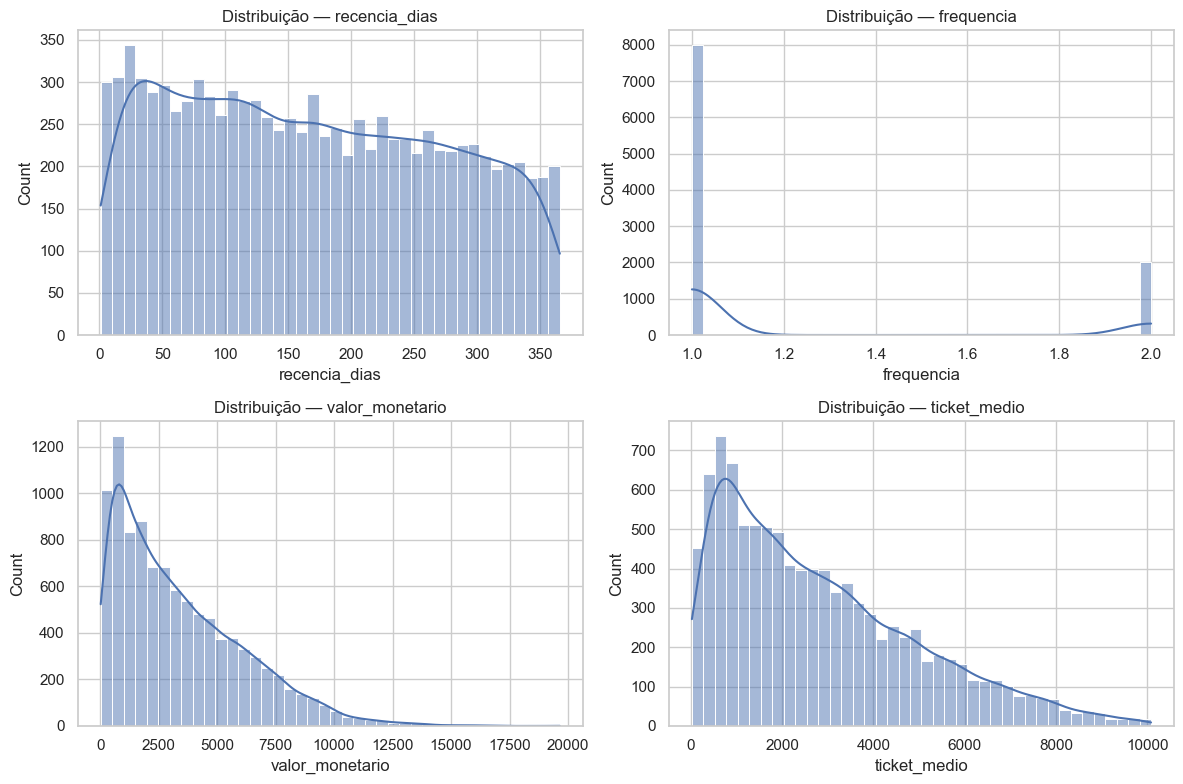

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, metricas_numericas):
    sns.histplot(data=df, x=var, bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribuição — {var}")
fig.tight_layout()
plt.show()

`valor_monetario`, `ticket_medio` e `frequencia` apresentam **assimetria à direita**: massa concentrada em valores baixos e cauda longa de poucos clientes muito acima da média. `recencia_dias` é mais espalhada, com tendência de concentração nos clientes recentes e uma cauda de inativos — a base do risco investigado em Q1.

### 4.2. Boxplots das métricas numéricas

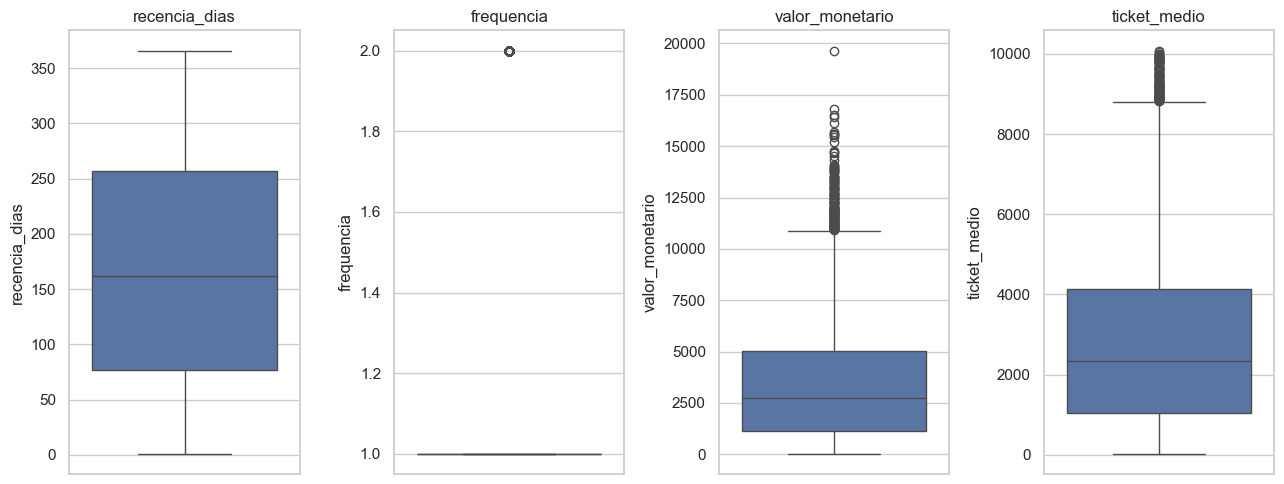

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(13, 5))
for ax, var in zip(axes, metricas_numericas):
    sns.boxplot(data=df, y=var, ax=ax)
    ax.set_title(var)
fig.tight_layout()
plt.show()

Os boxplots tornam visíveis os quartis e os pontos além dos *whiskers*. Em valor e frequência há muitos pontos acima do limite superior — coerente com a cauda longa observada nos histogramas. Esses pontos são **sinalizados**, não removidos.

### 4.3. Medidas de dispersão comparadas (desvio-padrão e IQR)

In [18]:
disp = []
for var in metricas_numericas:
    s = df[var]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    disp.append({
        "variavel": var,
        "desvio_padrao": s.std(),
        "amplitude": s.max() - s.min(),
        "IQR": q3 - q1,
    })
pd.DataFrame(disp)

,variavel,desvio_padrao,amplitude,IQR
0,recencia_dias,104.62,365.00,180.00
1,frequencia,0.40,1.00,0.00
2,valor_monetario,2738.80,19627.12,3909.50
3,ticket_medio,2153.52,10058.14,3114.41


Amplitude, desvio-padrão e IQR captam aspectos diferentes da variação. O contraste entre uma amplitude grande e um IQR pequeno (típico em valor e frequência) confirma que **a dispersão total é dominada por poucos extremos**, enquanto a metade central dos clientes é relativamente homogênea.

### 4.4. Assimetria (skewness)

In [19]:
assimetria = df[metricas_numericas].apply(lambda s: stats.skew(s, bias=False))
assimetria.sort_values(ascending=False).to_frame(name="skewness")

,skewness
frequencia,1.50
valor_monetario,1.05
ticket_medio,0.89
recencia_dias,0.16


Valores de assimetria claramente positivos (> 0) confirmam a cauda à direita em valor, ticket e frequência. Em variáveis assimétricas, a **mediana** descreve melhor o cliente típico do que a média.

### 4.5. Sinalização de outliers pelo critério do IQR

In [20]:
def outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (serie < li) | (serie > ls)
    return li, ls, mask.sum(), mask.mean() * 100

linhas_out = []
for var in metricas_numericas:
    li, ls, n, pct = outliers_iqr(df[var])
    linhas_out.append({"variavel": var, "limite_inf": round(li, 2),
                       "limite_sup": round(ls, 2), "n_outliers": n,
                       "pct_outliers_%": round(pct, 2)})
pd.DataFrame(linhas_out)

,variavel,limite_inf,limite_sup,n_outliers,pct_outliers_%
0,recencia_dias,-193.00,527.00,0,0.00
1,frequencia,1.00,1.00,2000,20.00
2,valor_monetario,-4723.80,10914.21,135,1.35
3,ticket_medio,-3638.39,8819.25,107,1.07


O critério `Q1 − 1,5·IQR` / `Q3 + 1,5·IQR` (o mesmo adotado no material da disciplina) é uma **triagem**, não uma regra de remoção. Os outliers superiores de `valor_monetario` provavelmente correspondem a clientes de altíssimo valor — casos raros **relevantes** para o negócio (Q3), e não erros. A decisão de tratamento pertence à etapa de modelagem, com base no dicionário de dados e nas regras de negócio.

### 4.6. Distribuição da frequência de compra

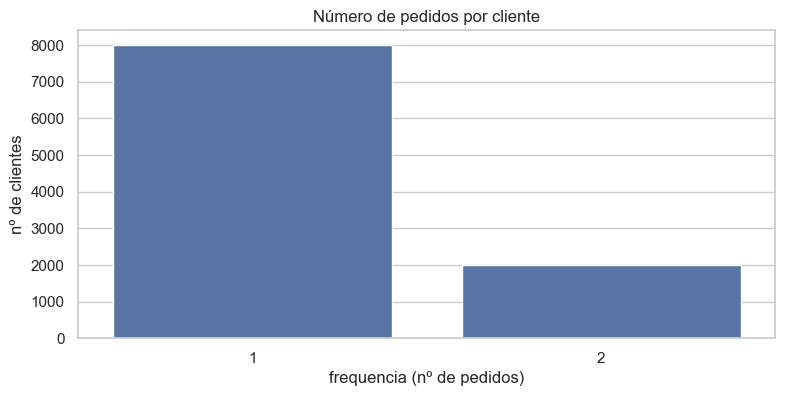

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=df, x="frequencia", ax=ax,
              order=sorted(df["frequencia"].unique()))
ax.set_title("Número de pedidos por cliente")
ax.set_xlabel("frequencia (nº de pedidos)")
ax.set_ylabel("nº de clientes")
plt.show()

A frequência é uma variável discreta fortemente concentrada em **1 pedido**, com queda acentuada para valores maiores. Esse formato é a evidência central para Q2: a fidelidade (recompra) é um comportamento minoritário na base.

### 4.7. Interpretação geral da seção
As métricas de valor e frequência são **assimétricas à direita**, com poucos clientes de alto valor sustentando a cauda; a recência distingue clientes recentes de uma cauda de inativos. Os outliers são, em boa parte, **casos raros relevantes** (alto valor) e devem ser preservados na exploração.

## 5. Relações iniciais entre variáveis

Saímos da análise univariada para investigar como as variáveis se comportam em conjunto.

### 5.1. Categórica × categórica: recompra por segmento

In [22]:
tab = pd.crosstab(df["segmento_cliente"], df["is_recomprador"])
display(tab)

prop_linha = pd.crosstab(df["segmento_cliente"], df["is_recomprador"], normalize="index") * 100
print("\nProporção por linha (% dentro de cada segmento):")
display(prop_linha.round(1))

is_recomprador,False,True
segmento_cliente,,
Em Risco,4878,522
Inativo,707,9
Leal,2415,1469



Proporção por linha (% dentro de cada segmento):


is_recomprador,False,True
segmento_cliente,,
Em Risco,90.3,9.7
Inativo,98.7,1.3
Leal,62.2,37.8


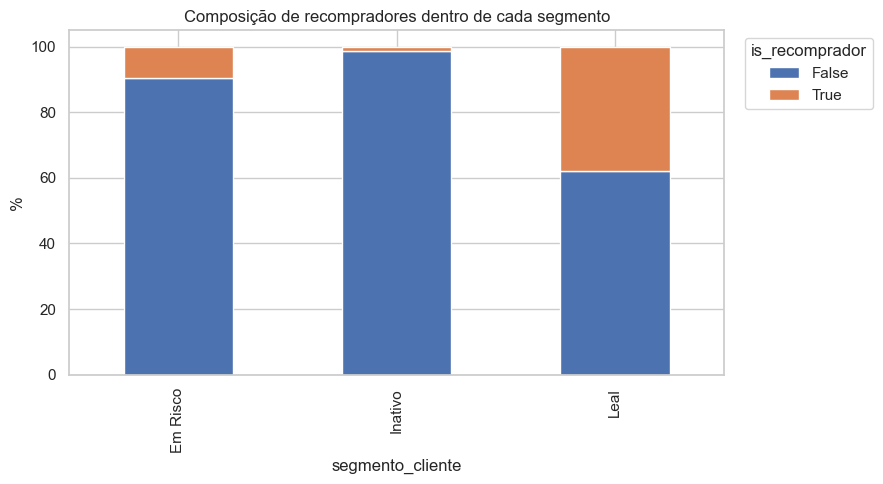

In [23]:
prop_linha.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Composição de recompradores dentro de cada segmento")
plt.ylabel("%")
plt.legend(title="is_recomprador", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

A proporção de recompradores muda conforme o segmento — indício exploratório de **associação** entre `segmento_cliente` e `is_recomprador`. Segmentos de maior valor concentram recompradores; segmentos de risco/inativos concentram clientes de compra única.

### 5.2. Numérica × numérica: dispersões

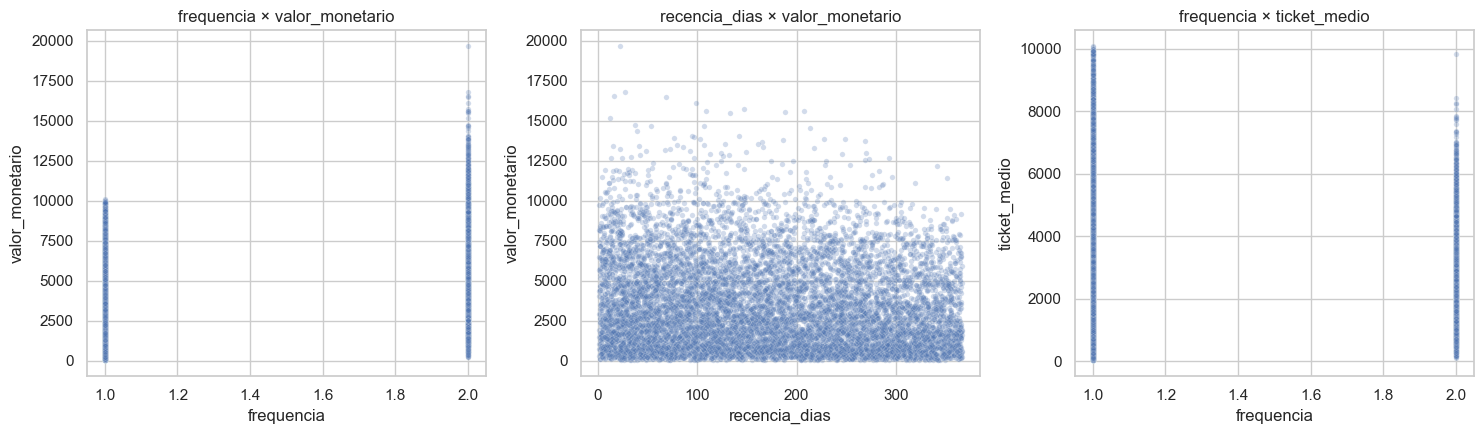

In [24]:
pares = [("frequencia", "valor_monetario"),
         ("recencia_dias", "valor_monetario"),
         ("frequencia", "ticket_medio")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (x, y) in zip(axes, pares):
    sns.scatterplot(data=df, x=x, y=y, alpha=0.25, s=15, ax=ax)
    ax.set_title(f"{x} × {y}")
fig.tight_layout()
plt.show()

`frequencia × valor_monetario` mostra relação positiva (comprar mais tende a somar mais receita). Já `frequencia × ticket_medio` aparece **sem relação clara**: clientes que compram com mais frequência não gastam necessariamente mais por pedido — leitura diretamente ligada a Q3-H2.

### 5.3. Correlação linear entre as métricas

,recencia_dias,frequencia,valor_monetario,ticket_medio
recencia_dias,1.00,-0.23,-0.11,-0.01
frequencia,-0.23,1.00,0.42,0.01
valor_monetario,-0.11,0.42,1.00,0.88
ticket_medio,-0.01,0.01,0.88,1.00


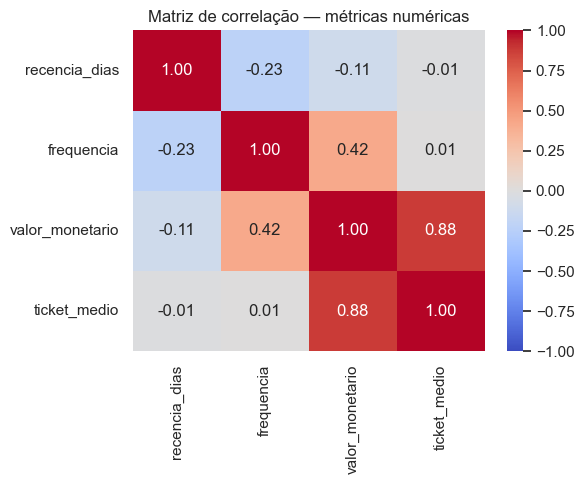

In [25]:
corr = df[metricas_numericas].corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlação — métricas numéricas")
plt.tight_layout()
plt.show()

### 5.4. Categórica × numérica: métricas por segmento

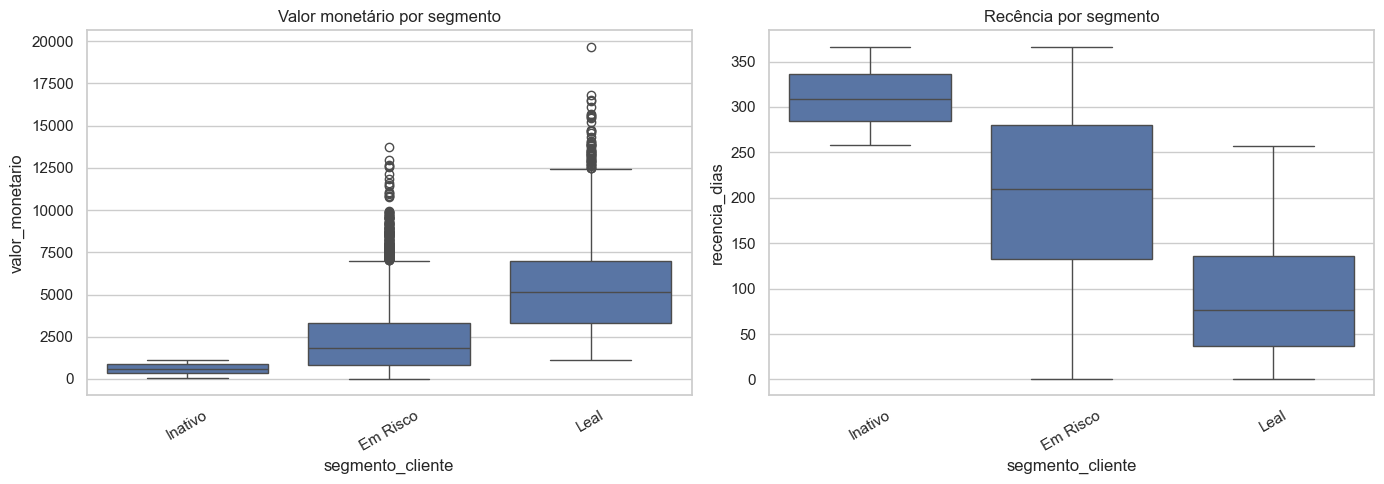

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ordem = df.groupby("segmento_cliente")["valor_monetario"].median().sort_values().index
sns.boxplot(data=df, x="segmento_cliente", y="valor_monetario", order=ordem, ax=axes[0])
axes[0].set_title("Valor monetário por segmento")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=df, x="segmento_cliente", y="recencia_dias", order=ordem, ax=axes[1])
axes[1].set_title("Recência por segmento")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

Há **contraste claro entre grupos**: segmentos de maior valor exibem distribuições de `valor_monetario` deslocadas para cima e recência menor (clientes mais recentes), enquanto segmentos inativos/de risco mostram o oposto. Isso sustenta o uso do segmento como eixo de decisão de marketing.

### 5.5. Média geral versus médias por grupo

In [27]:
geral = df["valor_monetario"].mean()
por_seg = df.groupby("segmento_cliente")["valor_monetario"].agg(["mean", "median", "count"])
por_seg["mean_vs_geral"] = por_seg["mean"] - geral
print(f"Média geral de valor_monetario: {geral:,.2f}")
por_seg.round(2)

Média geral de valor_monetario: 3,402.31


,mean,median,count,mean_vs_geral
segmento_cliente,,,,
Em Risco,2362.38,1820.62,5400,-1039.93
Inativo,598.56,599.30,716,-2803.75
Leal,5365.01,5136.69,3884,1962.69


A média geral esconde diferenças relevantes: ao segmentar, alguns grupos ficam muito acima e outros muito abaixo da média global. Resumos únicos sobre toda a base podem, portanto, **mascarar os subgrupos** que mais importam para a estratégia.

### 5.6. Interpretação geral da seção
As relações observadas convergem: valor caminha com frequência, mas **não com o ticket médio**; recência e valor separam segmentos; e a recompra concentra-se nos segmentos de maior valor. São indícios exploratórios alinhados a Q3, a serem testados formalmente adiante.

## 6. Padrões, tendências e anomalias exploratórias

### 6.1. Concentração de receita (Q3)

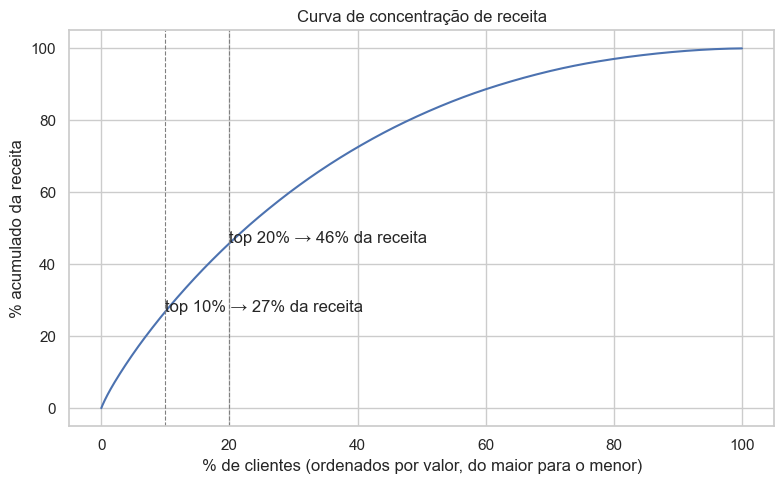

In [28]:
v = df["valor_monetario"].sort_values(ascending=False).reset_index(drop=True)
receita_acum = v.cumsum() / v.sum()
pct_clientes = (np.arange(1, len(v) + 1)) / len(v)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pct_clientes * 100, receita_acum * 100)
ax.set_xlabel("% de clientes (ordenados por valor, do maior para o menor)")
ax.set_ylabel("% acumulado da receita")
ax.set_title("Curva de concentração de receita")
for marca in [0.10, 0.20]:
    idx = int(marca * len(v)) - 1
    ax.axvline(marca * 100, color="gray", ls="--", lw=0.8)
    ax.annotate(f"top {int(marca*100)}% → {receita_acum.iloc[idx]*100:.0f}% da receita",
                (marca * 100, receita_acum.iloc[idx] * 100))
plt.tight_layout()
plt.show()

A curva mostra **concentração de receita**: uma fração reduzida de clientes responde por boa parte do faturamento (Q3-H1). O grau exato (ex.: quanto vem do top 20%) deve ser lido diretamente do gráfico/dados reais; a forma côncava acentuada é o que caracteriza a concentração, sem assumir a regra "80/20" a priori.

### 6.2. Contraste entre segmentos (medianas)

In [29]:
perfil = df.groupby("segmento_cliente").agg(
    n_clientes=("customer_id", "count"),
    recencia_mediana=("recencia_dias", "median"),
    frequencia_mediana=("frequencia", "median"),
    valor_mediano=("valor_monetario", "median"),
    ticket_mediano=("ticket_medio", "median"),
    receita_total=("valor_monetario", "sum"),
).sort_values("valor_mediano", ascending=False)
perfil["%_receita_total"] = (perfil["receita_total"] / df["valor_monetario"].sum() * 100).round(1)
perfil.round(2)

,n_clientes,recencia_mediana,frequencia_mediana,valor_mediano,ticket_mediano,receita_total,%_receita_total
segmento_cliente,,,,,,,
Leal,3884,77.0,1.0,5136.69,3788.41,2.08e+07,61.2
Em Risco,5400,210.0,1.0,1820.62,1690.46,1.28e+07,37.5
Inativo,716,309.0,1.0,599.30,587.95,4.29e+05,1.3


O perfil por segmento resume o diagnóstico: poucos segmentos de alto valor concentram a maior fatia da `receita_total`, enquanto segmentos numerosos de baixo valor contribuem pouco. É a tradução operacional do padrão de concentração para a ação de marketing.

### 6.3. Tendência temporal: aquisição de clientes ao longo de 2024

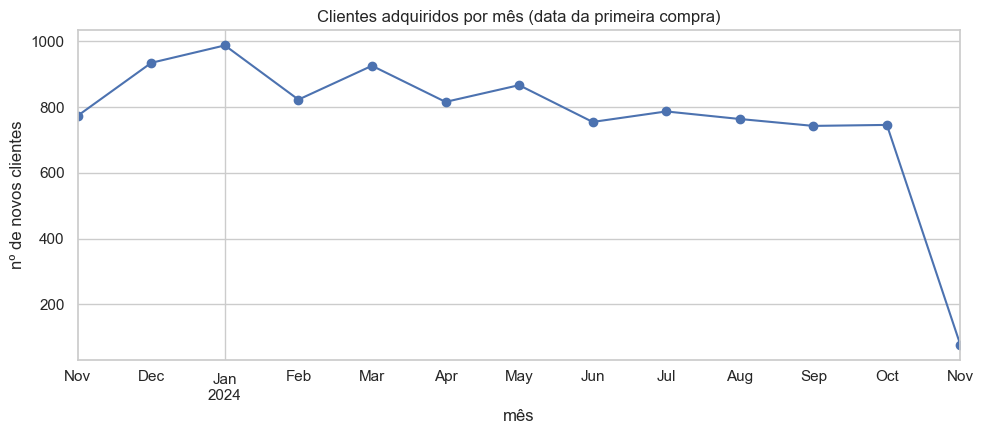

In [30]:
aquisicao = (df.set_index("primeira_compra")
               .resample("ME")["customer_id"].count())
fig, ax = plt.subplots(figsize=(10, 4.5))
aquisicao.plot(marker="o", ax=ax)
ax.set_title("Clientes adquiridos por mês (data da primeira compra)")
ax.set_xlabel("mês")
ax.set_ylabel("nº de novos clientes")
plt.tight_layout()
plt.show()

A série de **primeiras compras** descreve o ritmo de aquisição ao longo do ano. Variações entre meses sugerem sazonalidade na entrada de clientes (relacionada a Q1-H2); como tendência exploratória, deve ser confirmada com mais períodos antes de qualquer conclusão.

### 6.4. Anomalias exploratórias: inativos de alto valor

In [31]:
lim_recencia = df["recencia_dias"].quantile(0.75)   # 25% mais inativos
lim_valor = df["valor_monetario"].quantile(0.90)     # 10% mais valiosos
anomalos = df[(df["recencia_dias"] >= lim_recencia) & (df["valor_monetario"] >= lim_valor)]
print(f"Clientes com recência alta (>= P75={lim_recencia:.0f} dias) "
      f"E valor alto (>= P90={lim_valor:,.0f}): {len(anomalos)}")
anomalos[["customer_id", "recencia_dias", "frequencia",
          "valor_monetario", "segmento_cliente"]].head(10)

Clientes com recência alta (>= P75=257 dias) E valor alto (>= P90=7,320): 169


,customer_id,recencia_dias,frequencia,valor_monetario,segmento_cliente
13,14,282,1,7724.88,Em Risco
31,32,293,2,12656.60,Em Risco
122,123,291,1,7548.99,Em Risco
133,134,304,2,9749.54,Em Risco
174,175,297,2,8656.03,Em Risco
291,292,259,2,8465.43,Em Risco
298,299,350,1,8073.80,Em Risco
448,449,257,2,8007.98,Leal
467,468,282,1,7587.72,Em Risco
470,471,261,1,9122.00,Em Risco


Esse grupo — clientes valiosos que **pararam de comprar** — é um comportamento que merece investigação: representa receita em risco e é candidato natural a campanhas de reativação. O objetivo aqui é sinalizar o padrão, não corrigi-lo automaticamente.

### 6.5. Interpretação geral da seção
Três padrões se destacam: **concentração de receita** em poucos clientes (Q3), **contraste estrutural entre segmentos** (Q1) e a **predominância de compradores únicos** (Q2). A aquisição apresenta variação temporal e há um subgrupo relevante de inativos de alto valor.

## 7. Formulação de hipóteses exploratórias

Cada hipótese está vinculada a uma evidência do notebook e a uma pergunta investigável, é específica e plausível, e evita afirmações causais. São direções de investigação para etapas posteriores — não conclusões.

**H1 (Q2).** *A maioria dos clientes realiza apenas um pedido.*
Evidência: distribuição de `frequencia` fortemente concentrada em 1 (Seções 3.6 e 4.6).

**H2 (Q3).** *Uma fração reduzida de clientes concentra a maior parte da receita.*
Evidência: curva de concentração de receita acentuadamente côncava e `%_receita_total` por segmento (Seções 6.1 e 6.2).

**H3 (Q3).** *Maior frequência de compra não está associada a maior ticket médio.*
Evidência: dispersão `frequencia × ticket_medio` sem padrão e correlação próxima de zero (Seções 5.2 e 5.3).

**H4 (Q1).** *Clientes de alta recência (inativos) concentram-se em segmentos de baixo valor, mas existe um subgrupo de inativos de alto valor.*
Evidência: boxplots de `recencia_dias`/`valor_monetario` por segmento e o grupo anômalo identificado (Seções 5.4 e 6.4).

**H5 (Q1).** *O volume de aquisição de clientes varia ao longo dos meses de 2024.*
Evidência: série mensal de primeiras compras com oscilação entre períodos (Seção 6.3).

## 8. Síntese final

A AED da camada gold (10.000 clientes, perfil RFM) indica uma base **assimétrica**: a maioria compra uma única vez e contribui pouco, enquanto poucos clientes de alto valor sustentam grande parte da receita (**Q3**). A recência separa clientes recentes de uma cauda de inativos, e os segmentos diferem de forma marcante em valor e recência (**Q1**); a recompra é minoritária e concentrada nos segmentos de maior valor (**Q2**). Frequência e valor caminham juntos, mas frequência e ticket médio são praticamente independentes.

Esses achados são **exploratórios**: orientam as hipóteses H1–H5 e a etapa de segmentação/modelagem, sem estabelecer relações causais nem conclusões definitivas a partir das evidências aqui observadas.